In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = "/home/yusuf/quant/drl-crypto/data/processed/1s/ADAUSDT/ADAUSDT-1s-2025-05.parquet"
df = pd.read_parquet(path)
df.head()

,ts,price_last,buy_qty,sell_qty
0,2025-05-01 00:00:00,0.6816,1346.2,0.0
1,2025-05-01 00:00:02,0.6816,0.0,1254.9
2,2025-05-01 00:00:04,0.6816,0.0,17.5
3,2025-05-01 00:00:05,0.6816,7.4,7.4
4,2025-05-01 00:00:06,0.6818,142.6,0.0


In [13]:
def get_ofi(df, n=60):
    buy_flow = (df.buy_qty*df.price_last).rolling(n).sum()
    sell_flow = (df.sell_qty*df.price_last).rolling(n).sum()
    ofi = (buy_flow - sell_flow) / (buy_flow + sell_flow)
    return ofi
def get_log_ret(df, n=60):
    log_ret = np.log(df.price_last / df.price_last.shift(n))
    return log_ret
def get_log_volume(df, n=60):
    volume = df.buy_qty * df.price_last + df.sell_qty * df.price_last
    log_volume = np.log(volume.replace([0],1)).rolling(n).sum()
    return log_volume

def normalize_zscore(series, window=60):
    mean = series.rolling(window).mean()
    std = series.rolling(window).std()
    return (series - mean) / std


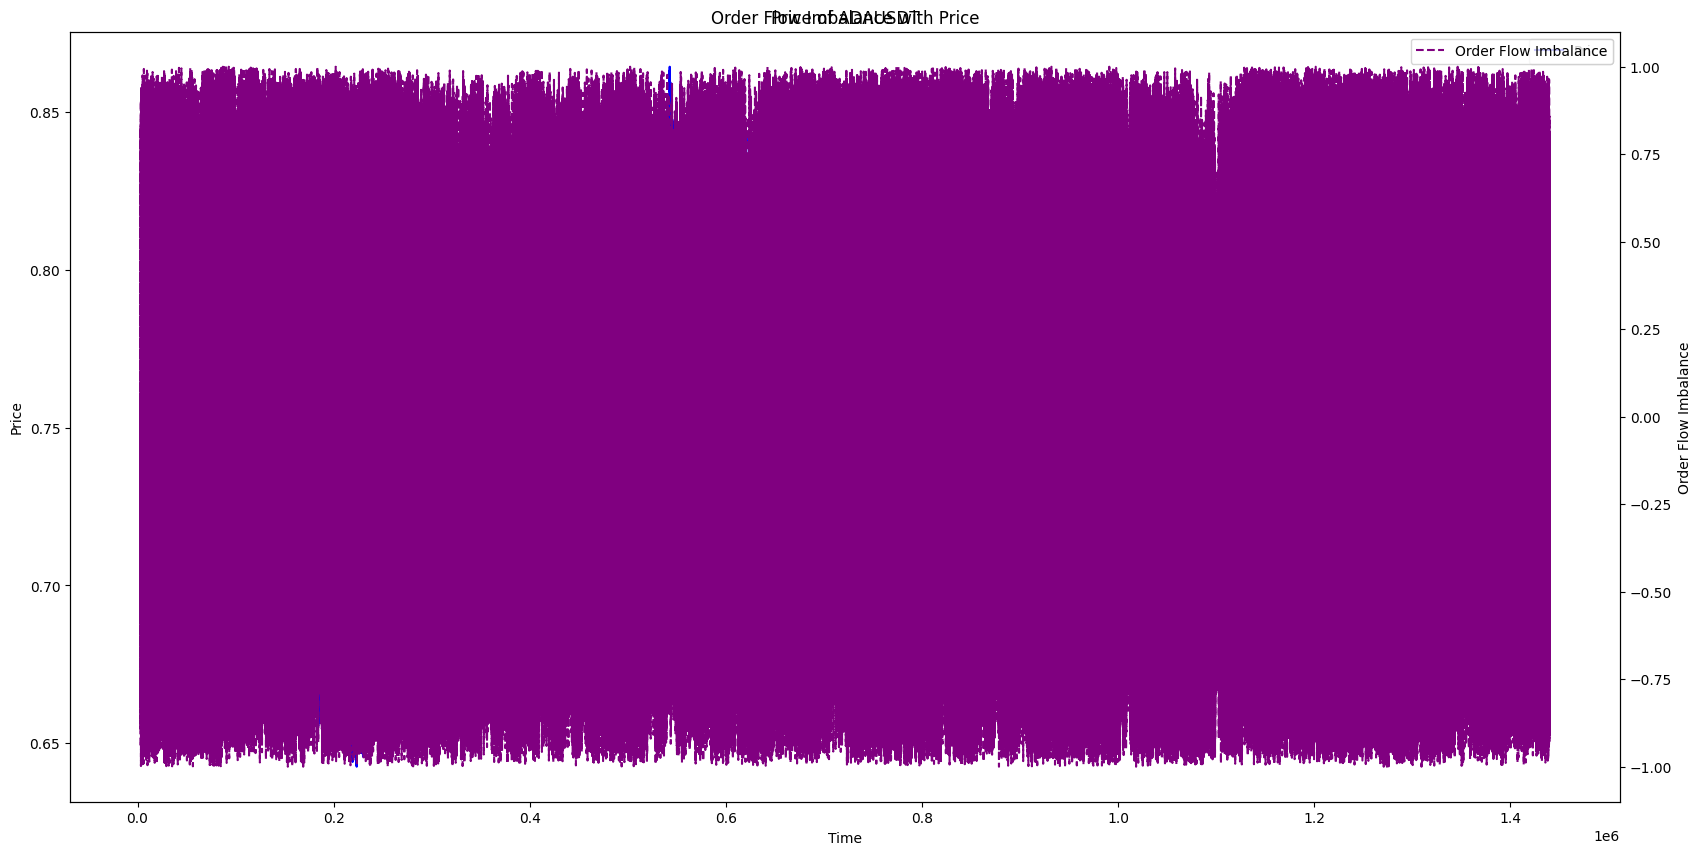

In [26]:
fig,ax = plt.subplots(figsize=(20, 10))
df.price_last.plot(ax=ax, label="Price", color="blue")
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.legend()
ax.set_title("Price of ADAUSDT")
ax_ofi = ax.twinx()
df["ofi"] = get_ofi(df, 20)
df.ofi.plot(ax=ax_ofi, label="Order Flow Imbalance", color="purple", linestyle='--')
ax_ofi.set_ylabel("Order Flow Imbalance")
ax_ofi.legend()
plt.title("Order Flow Imbalance with Price")
plt.show()


In [27]:
path_fet = "/home/yusuf/quant/drl-crypto/data/features/1s/ADAUSDT-1s-2025-05.parquet"
X = pd.read_parquet(path_fet)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1439945 entries, 0 to 1439944
Data columns (total 19 columns):
 #   Column                         Non-Null Count    Dtype         
---  ------                         --------------    -----         
 0   ts                             1439945 non-null  datetime64[ms]
 1   price_last                     1439945 non-null  float64       
 2   buy_qty                        1439945 non-null  float64       
 3   sell_qty                       1439945 non-null  float64       
 4   log_ret_20_zscore_1200         1439923 non-null  float64       
 5   log_ret_60_zscore_3600         1439883 non-null  float64       
 6   log_ret_180_zscore_10800       1439763 non-null  float64       
 7   log_ret_600_zscore_36000       1439344 non-null  float64       
 8   log_ret_1800_zscore_108000     1438143 non-null  float64       
 9   log_volume_20_zscore_1200      1439944 non-null  float64       
 10  log_volume_60_zscore_3600      1439944 non-null  float

In [28]:
df["ofi_20_zscore_1200"] = normalize_zscore(df.ofi, 1200)

In [29]:
df = df.dropna()
X = X.dropna()
print(df.shape, X.shape)

(1435729, 6) (1438143, 19)


<Axes: >

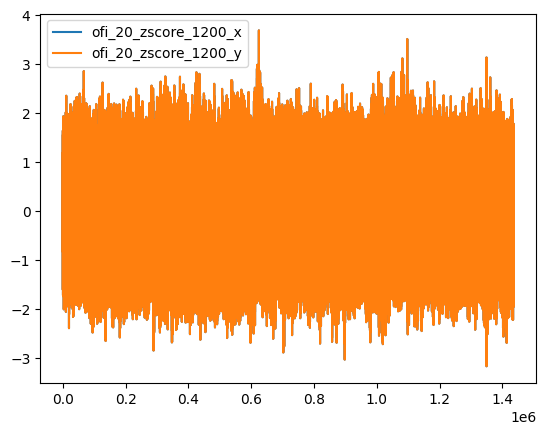

In [ ]:
 = pd.merge(df[["ts", "ofi_20_zscore_1200"]], X[["ts", "ofi_20_zscore_1200" ]], on="ts", how="inner")